<a href="https://colab.research.google.com/github/sukritimahajan35/Hindi-Audio-Sentiment-Analysis-Using-Machine-Learning-and-Deep-Learning/blob/main/CNN_LSTM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Import Libraries
import os
import librosa
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, TimeDistributed, LSTM, Dense, Dropout, Flatten, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Navigate to Dataset Directory
dataset_path = '/content/drive/MyDrive/Dataset'
os.chdir(dataset_path)

Mounted at /content/drive


In [ ]:
# Extract File Paths and Labels
def extract_dataset(base_path):
    data = []
    emotions = ['anger', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'sarcastic', 'surprise']

    # Sort actor folders numerically
    actor_folders = sorted(os.listdir(base_path), key=lambda x: int(x))

    for actor_folder in actor_folders:
        actor_path = os.path.join(base_path, actor_folder)
        if os.path.isdir(actor_path):
            # Sort session folders numerically
            session_folders = sorted(os.listdir(actor_path), key=lambda x: int(x.split('session')[-1]))

            for session_folder in session_folders:
                session_path = os.path.join(actor_path, session_folder)
                if os.path.isdir(session_path):
                    for emotion in emotions:
                        emotion_path = os.path.join(session_path, emotion)
                        if os.path.isdir(emotion_path):
                            # Sort audio files numerically
                            audio_files = sorted(os.listdir(emotion_path), key=lambda x: int(x.split('-')[-1].split('.')[0]))

                            for audio_file in audio_files:
                                data.append((os.path.join(emotion_path, audio_file), emotion))
    return pd.DataFrame(data, columns=['file_path', 'emotion'])

# Extract dataset
df = extract_dataset(dataset_path)
print(df.head())

                                           file_path emotion
0  /content/drive/MyDrive/Dataset/1/session1/ange...   anger
1  /content/drive/MyDrive/Dataset/1/session1/ange...   anger
2  /content/drive/MyDrive/Dataset/1/session1/ange...   anger
3  /content/drive/MyDrive/Dataset/1/session1/ange...   anger
4  /content/drive/MyDrive/Dataset/1/session1/ange...   anger


In [ ]:
# Data Augmentation
def augment_audio(y, sr):
    """
    Apply pitch shifting and time stretching to augment the audio signal.
    """
    y_pitch = librosa.effects.pitch_shift(y, sr=sr, n_steps=2)
    y_stretch = librosa.effects.time_stretch(y, rate=0.8)
    return np.concatenate([y, y_pitch, y_stretch])

In [ ]:
# Feature Extraction
def extract_features(y, sr):
    """
    Extract robust features such as ZCR, Spectral Centroid, RMS Energy, and MFCCs.
    Handles short signals by padding them to a minimum length.
    """
    min_length = 1024  # Minimum length required for feature extraction

    # Handle short signals
    if len(y) < min_length:
        print(f"Padding short signal: {len(y)} samples")
        y = np.pad(y, (0, min_length - len(y)), mode='constant')  # Zero-pad to min_length samples

    # Zero-Crossing Rate
    zcr = librosa.feature.zero_crossing_rate(y).mean()

    # Spectral Centroid
    spectral_centroid = librosa.feature.spectral_centroid(y=y, sr=sr).mean()

    # Root Mean Square Energy
    rms_energy = librosa.feature.rms(y=y).mean()

    # MFCCs
    mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13).mean(axis=1)

    # Combine all features
    feature_vector = np.hstack([zcr, spectral_centroid, rms_energy, mfccs])
    return feature_vector

In [ ]:
from sklearn.preprocessing import StandardScaler
# Preprocessing Pipeline with Augmentation and Feature Extraction
def preprocess_data(df):
    features = []
    labels = []
    for idx, row in df.iterrows():
        try:
            y, sr = librosa.load(row['file_path'], sr=None)

            # Step 1: Noise Reduction
            y = librosa.effects.preemphasis(y)

            # Step 2: Silence Removal
            intervals = librosa.effects.split(y, top_db=20)
            y = np.concatenate([y[start:end] for start, end in intervals])

            # Step 3: Data Augmentation
            y_augmented = augment_audio(y, sr)

            # Step 4: Feature Extraction
            feature_vector = extract_features(y_augmented, sr)
            features.append(feature_vector)
            labels.append(row['emotion'])
        except Exception as e:
            print(f"Error processing file {row['file_path']}: {e}")

    features = np.array(features)
    scaler = StandardScaler()
    features = scaler.fit_transform(features)  # Normalize features
    return features, np.array(labels)

# Apply Preprocessing
X, y = preprocess_data(df)

In [ ]:
# Encode Labels and Split Data
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42)

In [ ]:
# Reshape Data for CNN+LSTM
X_train_cnnlstm = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test_cnnlstm = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

In [ ]:
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, LSTM, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping, ModelCheckpoint
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

def build_improved_cnn_lstm_model(input_shape, num_classes):
    model = Sequential()

    # 1D CNN Layers - Feature Extraction
    model.add(Conv1D(filters=64, kernel_size=3, activation='relu', input_shape=input_shape))
    model.add(BatchNormalization())
    model.add(MaxPooling1D(pool_size=2))
    model.add(Dropout(0.25))

    model.add(Conv1D(filters=128, kernel_size=3, activation='relu'))
    model.add(BatchNormalization())
    model.add(MaxPooling1D(pool_size=2))
    model.add(Dropout(0.25))

    # LSTM Layer - Temporal Understanding
    model.add(LSTM(128, return_sequences=False))  # Use `return_sequences=True` if adding another LSTM
    model.add(Dropout(0.3))

    # Fully Connected Output Layers
    model.add(Dense(128, activation='relu'))
    model.add(BatchNormalization())
    model.add(Dropout(0.4))

    model.add(Dense(num_classes, activation='softmax'))

    # Compile with tuned learning rate
    optimizer = Adam(learning_rate=0.0005)
    model.compile(optimizer=optimizer,
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

    return model


# Build the improved model
cnn_lstm_model = build_improved_cnn_lstm_model(
    input_shape=(X_train_cnnlstm.shape[1], 1),
    num_classes=len(np.unique(y_encoded))
)

# Callbacks
callbacks = [
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1),
    EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True),
    ModelCheckpoint('best_model.keras', monitor='val_accuracy', save_best_only=True, mode='max')
]

# Train
history = cnn_lstm_model.fit(
    X_train_cnnlstm, y_train,
    epochs=70,
    batch_size=64,
    validation_split=0.2,
    callbacks=callbacks,
    verbose=1
)

# Evaluate
y_pred = np.argmax(cnn_lstm_model.predict(X_test_cnnlstm), axis=1)

print("Accuracy:", accuracy_score(y_test, y_pred))

Epoch 1/70


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


32/32 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - accuracy: 0.1417 - loss: 3.0375 - val_accuracy: 0.1602 - val_loss: 2.0761 - learning_rate: 5.0000e-04
Epoch 2/70
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.1642 - loss: 2.7567 - val_accuracy: 0.1348 - val_loss: 2.0716 - learning_rate: 5.0000e-04
Epoch 3/70
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.1858 - loss: 2.5821 - val_accuracy: 0.1211 - val_loss: 2.0667 - learning_rate: 5.0000e-04
Epoch 4/70
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.2094 - loss: 2.4058 - val_accuracy: 0.1230 - val_loss: 2.0625 - learning_rate: 5.0000e-04
Epoch 5/70
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.2293 - loss: 2.3048 - val_accuracy: 0.1504 - val_loss: 2.0540 - learning_rate: 5.0000e-04
Epoch 6/70
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.2283 - loss: 2.2265 - val_accuracy: 0.1660 - val_loss: 2.0411 - learning_rate: 5.0000e-04
Epoch 7/70
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.2297 - loss: 2.2


Classification Report:
              precision    recall  f1-score   support

       anger       0.65      0.62      0.64        82
     disgust       0.51      0.51      0.51        87
        fear       0.51      0.56      0.53        70
       happy       0.49      0.63      0.55        71
     neutral       0.52      0.51      0.51        86
         sad       0.54      0.53      0.53        76
   sarcastic       0.51      0.39      0.45        89
    surprise       0.52      0.53      0.53        79

    accuracy                           0.53       640
   macro avg       0.53      0.54      0.53       640
weighted avg       0.53      0.53      0.53       640



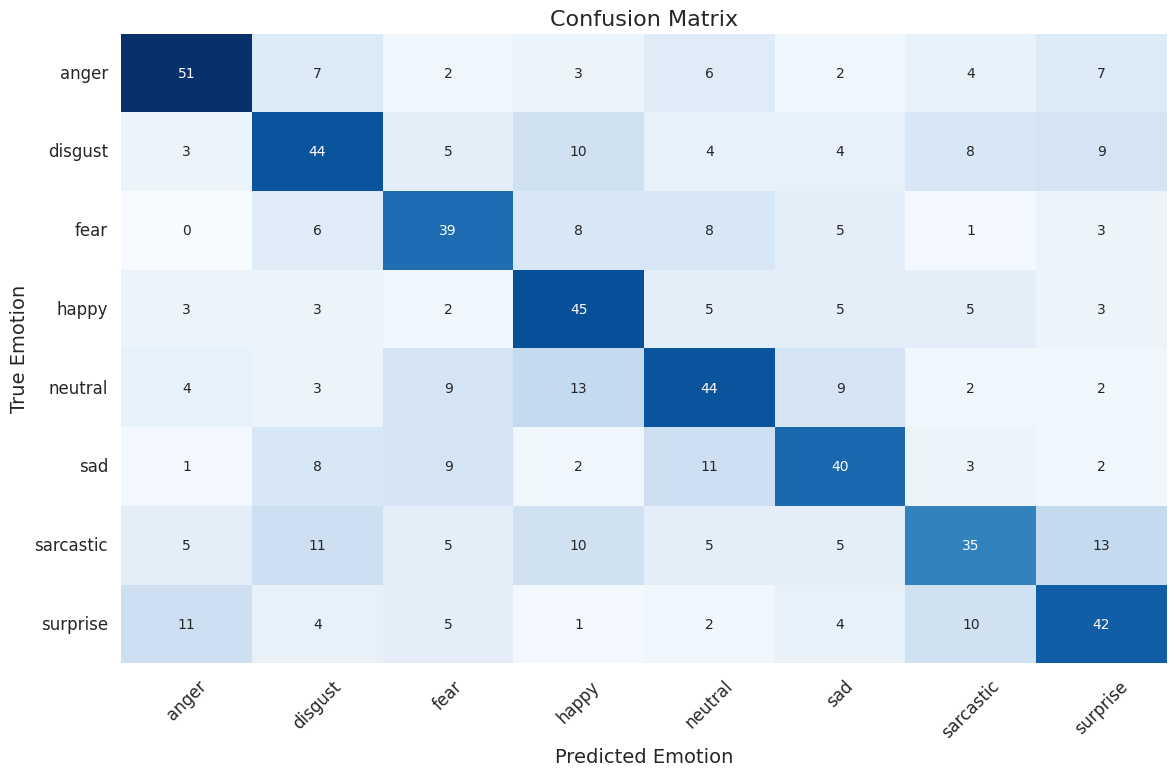

In [ ]:
# Classification Report
report = classification_report(y_test, y_pred, target_names=label_encoder.classes_)
print("\nClassification Report:")
print(report)
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

# Plot Confusion Matrix
plt.figure(figsize=(12, 8))
sns.set(font_scale=1.2)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_,
            annot_kws={"size": 10}, cbar=False)

# Add Labels and Title
plt.title('Confusion Matrix', fontsize=16)
plt.xlabel('Predicted Emotion', fontsize=14)
plt.ylabel('True Emotion', fontsize=14)
plt.xticks(rotation=45, fontsize=12)
plt.yticks(rotation=0, fontsize=12)
plt.tight_layout()
plt.show()